# 🤹 Multi-Task Learning (MTL)

**Multi-Task Learning (MTL)** is an approach where a single model is trained to solve **multiple related tasks simultaneously**.

### The Core Idea: Shared Representation

Instead of training separate models for Task A and Task B, MTL forces the model to learn a **shared feature representation** (the backbone) that benefits all tasks. For our example, learning the sharp edges and curves that define the digit '3' also helps determine its parity (odd).

This mechanism acts as a powerful form of **regularization**, as the shared layers must generalize well and avoid overfitting to the idiosyncrasies of any single task.

### Architecture: Hard Parameter Sharing

We implement **Hard Parameter Sharing**, the most common MTL architecture:

1.  **Shared Layers (Backbone):** The initial CNN layers that extract features.
2.  **Task-Specific Layers (Heads):** Separate classification layers that branch off the backbone, one for each task.

## 1. Setup and The Dual-Task Dataset

We modify the standard MNIST dataset to generate two labels for every input: the original digit and its parity (0 for Even, 1 for Odd).

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Configuration
BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Custom Multi-Task Dataset ---
class MultiTaskMNIST(Dataset):
    def __init__(self, root, train=True, transform=None):
        # Load the base MNIST dataset
        self.base_dataset = datasets.MNIST(root=root, train=train, download=True, transform=transform)

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, target_digit = self.base_dataset[idx]

        # Task B Label Generation: Parity
        # 0 if even (0, 2, 4, 6, 8), 1 if odd (1, 3, 5, 7, 9)
        target_parity = target_digit % 2

        # Return image, target_digit, target_parity
        return img, target_digit, target_parity

# Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load Data
train_dataset = MultiTaskMNIST(root='./data', train=True, transform=transform)
test_dataset = MultiTaskMNIST(root='./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Using device: cuda


## 2. The Multi-Task Architecture

The model features a single **backbone** that feeds its output into two distinct and task-specific **heads**.

In [3]:
class MultiTaskModel(nn.Module):
    def __init__(self):
        super(MultiTaskModel, self).__init__()

        # --- 1. Shared Backbone (Feature Extractor) ---
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Output spatial size: 14x14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Output spatial size: 7x7

            nn.Flatten()
        )

        # Calculate backbone output size: 64 channels * 7 * 7 spatial
        self.backbone_out_features = 64 * 7 * 7

        # --- 2. Task A Head: Digit Classification (10 classes) ---
        self.digit_head = nn.Sequential(
            nn.Linear(self.backbone_out_features, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

        # --- 3. Task B Head: Parity Classification (2 classes) ---
        self.parity_head = nn.Sequential(
            nn.Linear(self.backbone_out_features, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        # 1. Extract shared features
        shared_features = self.backbone(x)

        # 2. Pass features to Task A head
        out_digit = self.digit_head(shared_features)

        # 3. Pass features to Task B head
        out_parity = self.parity_head(shared_features)

        return out_digit, out_parity

model = MultiTaskModel().to(device)

## 3. The Multi-Task Loss Function

We combine the individual loss functions using a **Weighted Sum of Losses**:
$$L_{total} = L_{digit} + L_{parity}$$

The gradients from both tasks flow back and update the **shared backbone**, forcing it to learn features that minimize both errors simultaneously.

In [4]:
# Separate loss functions for each head
criterion_digit = nn.CrossEntropyLoss()
criterion_parity = nn.CrossEntropyLoss()

# Single optimizer for ALL parameters (backbone + both heads)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

def multitask_loss(out_digit, target_digit, out_parity, target_parity):
    # Calculate individual losses
    loss_digit = criterion_digit(out_digit, target_digit)
    loss_parity = criterion_parity(out_parity, target_parity)

    # Combine them (simple 1:1 sum)
    total_loss = loss_digit + loss_parity

    return total_loss, loss_digit, loss_parity

## 4. Training Loop

The loop is modified to handle two target labels and backpropagate using the single combined loss.

In [5]:
print(f"Starting Multi-Task Training for {NUM_EPOCHS} epochs...")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    running_loss_d = 0.0
    running_loss_p = 0.0

    for inputs, labels_digit, labels_parity in train_loader:
        inputs, labels_digit, labels_parity = inputs.to(device), labels_digit.to(device), labels_parity.to(device)

        optimizer.zero_grad()

        # Forward pass: Get outputs for BOTH heads
        out_digit, out_parity = model(inputs)

        # Compute combined loss
        loss, l_d, l_p = multitask_loss(out_digit, labels_digit, out_parity, labels_parity)

        # Backpropagate based on the combined loss
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_loss_d += l_d.item()
        running_loss_p += l_p.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Total Loss: {avg_loss:.4f} (Digit: {running_loss_d/len(train_loader):.4f}, Parity: {running_loss_p/len(train_loader):.4f})")

Starting Multi-Task Training for 10 epochs...
Epoch 1/10 | Total Loss: 0.2090 (Digit: 0.1311, Parity: 0.0780)
Epoch 2/10 | Total Loss: 0.0668 (Digit: 0.0415, Parity: 0.0253)
Epoch 3/10 | Total Loss: 0.0456 (Digit: 0.0272, Parity: 0.0184)
Epoch 4/10 | Total Loss: 0.0329 (Digit: 0.0201, Parity: 0.0128)
Epoch 5/10 | Total Loss: 0.0246 (Digit: 0.0159, Parity: 0.0088)
Epoch 6/10 | Total Loss: 0.0212 (Digit: 0.0124, Parity: 0.0088)
Epoch 7/10 | Total Loss: 0.0146 (Digit: 0.0094, Parity: 0.0052)
Epoch 8/10 | Total Loss: 0.0127 (Digit: 0.0085, Parity: 0.0043)
Epoch 9/10 | Total Loss: 0.0127 (Digit: 0.0091, Parity: 0.0035)
Epoch 10/10 | Total Loss: 0.0105 (Digit: 0.0066, Parity: 0.0039)


## 5. Evaluation and Inference

We evaluate the final accuracy for both tasks independently.

In [6]:
def evaluate_multitask(model, loader):
    model.eval()

    correct_digit = 0
    correct_parity = 0
    total = 0

    with torch.no_grad():
        for inputs, labels_digit, labels_parity in loader:
            inputs, labels_digit, labels_parity = inputs.to(device), labels_digit.to(device), labels_parity.to(device)

            out_digit, out_parity = model(inputs)

            # Digit Accuracy
            _, preds_digit = torch.max(out_digit, 1)
            correct_digit += (preds_digit == labels_digit).sum().item()

            # Parity Accuracy
            _, preds_parity = torch.max(out_parity, 1)
            correct_parity += (preds_parity == labels_parity).sum().item()

            total += labels_digit.size(0)

    acc_digit = correct_digit / total
    acc_parity = correct_parity / total

    return acc_digit, acc_parity

acc_d, acc_p = evaluate_multitask(model, test_loader)

print("--- Final Results ---")
print(f"Digit Classification Accuracy: {acc_d*100:.2f}%")
print(f"Parity Classification Accuracy: {acc_p*100:.2f}%")

--- Final Results ---
Digit Classification Accuracy: 99.19%
Parity Classification Accuracy: 99.38%


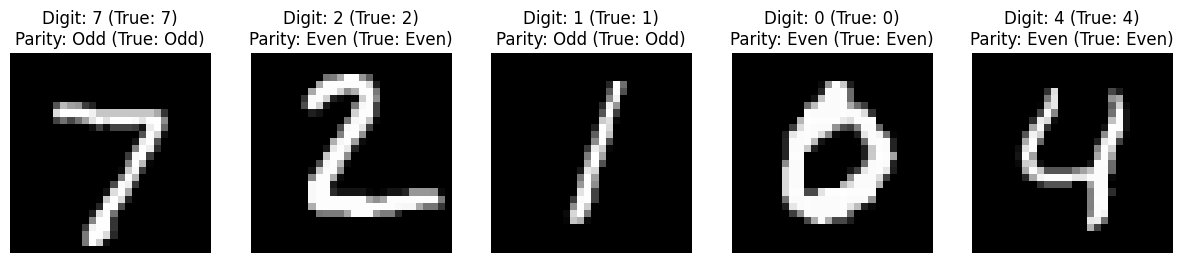

In [8]:
# --- Inference Visualization ---
# Get a batch
inputs, l_d, l_p = next(iter(test_loader))
inputs = inputs.to(device)

# Predict
model.eval()
with torch.no_grad():
    o_d, o_p = model(inputs)
    _, p_d = torch.max(o_d, 1)
    _, p_p = torch.max(o_p, 1)

# Plot
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = inputs[i].cpu().squeeze()

    # Original image is normalized; display after reversing normalization for better view
    img = img * 0.3081 + 0.1307

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Digit: {p_d[i].item()} (True: {l_d[i].item()})\nParity: {'Odd' if p_p[i].item() else 'Even'} (True: {'Odd' if l_p[i].item() else 'Even'})")
    axes[i].axis('off')

plt.show()

## 6. Conclusion

We successfully implemented a **Multi-Task Learning** network:

1.  **Shared Features:** The CNN backbone learned features (like shapes and curves) that were useful for *both* identifying the specific digit and determining its even/odd status.
2.  **Efficiency:** The expensive feature extraction (the backbone) is computed only once for both tasks.
3.  **Cross-Task Regularization:** The process of optimizing for two related tasks often forces the shared parameters to settle on a more generalized and robust solution than if it were trained for a single task alone.

**The main challenge in real-world MTL remains Loss Balancing**—ensuring one task's loss doesn't overwhelm the other's gradients, which we kept simple here with a 1:1 sum.